# Notebook 2: Supervised Modeling — Regression & Classification
 
Train, tune, and track ML models for price prediction and order classification using MLflow.

---

## 2.1 Setup & Load Artifacts from Notebook 1

In [1]:
!pip install mlflow scikit-learn imbalanced-learn pandas numpy matplotlib seaborn joblib -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              ConfusionMatrixDisplay, log_loss)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded!")

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded!


In [3]:
# Load artifacts from Notebook 1
df          = pd.read_csv('../artifacts/cleaned_data.csv')
preprocessor = joblib.load('../artifacts/preprocessor.joblib')
le_delivery  = joblib.load('../artifacts/le_delivery.joblib')
le_segment   = joblib.load('../artifacts/le_segment.joblib')

print(f"Data loaded: {df.shape}")
print("Delivery classes:", le_delivery.classes_)
print("Segment classes: ", le_segment.classes_)

Data loaded: (10000, 13)
Delivery classes: ['Delivered' 'Pending' 'Returned' 'Shipped']
Segment classes:  ['New' 'Returning' 'VIP']


In [4]:
# Define features and targets
target_cols = ['price', 'delivery_status', 'customer_segment']
X = df.drop(columns=target_cols, errors='ignore')

y_price    = df['price'].values
y_delivery = le_delivery.transform(df['delivery_status'])
y_segment  = le_segment.transform(df['customer_segment'])

# Apply preprocessor
X_processed = preprocessor.transform(X)
print(f"Feature matrix shape: {X_processed.shape}")

Feature matrix shape: (10000, 24)


---
# PART A — REGRESSION: Predicting Order Price
## 2.2 Train/Test Split for Regression

In [5]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_processed, y_price, test_size=0.2, random_state=42
)

print(f"Regression split → Train: {X_train_r.shape}, Test: {X_test_r.shape}")

Regression split → Train: (8000, 24), Test: (2000, 24)


## 2.3 MLflow Experiment Tracking — Regression

We record numerous training processes under a variable setting of parameters.  
MLflow system saves all parameters, metrics, and model artifacts required.

In [6]:
# Set MLflow tracking URI to local artifacts directory
mlflow.set_tracking_uri("file:../mlruns")

mlflow.set_experiment("auracart_price_regression")

# --- Run 1: Standard Multiple Linear Regression ---
with mlflow.start_run(run_name="LinearRegression_baseline"):
    model_lr = LinearRegression()
    model_lr.fit(X_train_r, y_train_r)
    y_pred_lr = model_lr.predict(X_test_r)

    mse_lr  = mean_squared_error(y_test_r, y_pred_lr)
    mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
    r2_lr   = r2_score(y_test_r, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("fit_intercept", True)
    mlflow.log_metric("MSE",  mse_lr)
    mlflow.log_metric("MAE",  mae_lr)
    mlflow.log_metric("RMSE", rmse_lr)
    mlflow.log_metric("R2",   r2_lr)
    mlflow.sklearn.log_model(model_lr, "linear_regression_model")

    print(f"[LinearRegression] MSE={mse_lr:.2f} | MAE={mae_lr:.2f} | RMSE={rmse_lr:.2f} | R²={r2_lr:.4f}")

2026/04/05 22:20:11 INFO mlflow.tracking.fluent: Experiment with name 'auracart_price_regression' does not exist. Creating a new experiment.
2026/04/05 22:20:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:20:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LinearRegression] MSE=20659.33 | MAE=123.97 | RMSE=143.73 | R²=-0.0015


In [7]:
# --- Run 2: SGD Regressor (simulates gradient descent with lr tuning) ---
sgd_configs = [
    {'eta0': 0.001, 'max_iter': 500,  'learning_rate': 'constant'},
    {'eta0': 0.01,  'max_iter': 1000, 'learning_rate': 'invscaling'},
    {'eta0': 0.005, 'max_iter': 2000, 'learning_rate': 'adaptive'},
]

for cfg in sgd_configs:
    run_name = f"SGDRegressor_lr{cfg['eta0']}_iter{cfg['max_iter']}"
    with mlflow.start_run(run_name=run_name):
        model_sgd = SGDRegressor(
            eta0=cfg['eta0'],
            max_iter=cfg['max_iter'],
            learning_rate=cfg['learning_rate'],
            random_state=42,
            early_stopping=True
        )
        model_sgd.fit(X_train_r, y_train_r)
        y_pred_sgd = model_sgd.predict(X_test_r)

        mse  = mean_squared_error(y_test_r, y_pred_sgd)
        mae  = mean_absolute_error(y_test_r, y_pred_sgd)
        r2   = r2_score(y_test_r, y_pred_sgd)
        rmse = np.sqrt(mse)

        mlflow.log_params(cfg)
        mlflow.log_param("model_type", "SGDRegressor")
        mlflow.log_metric("MSE",  mse)
        mlflow.log_metric("MAE",  mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2",   r2)
        mlflow.sklearn.log_model(model_sgd, "sgd_regressor_model")

        print(f"[{run_name}] MSE={mse:.2f} | MAE={mae:.2f} | R²={r2:.4f}")

2026/04/05 22:20:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:20:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/05 22:20:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SGDRegressor_lr0.001_iter500] MSE=20742.25 | MAE=124.31 | R²=-0.0056


2026/04/05 22:20:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/05 22:20:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SGDRegressor_lr0.01_iter1000] MSE=20680.71 | MAE=124.02 | R²=-0.0026


2026/04/05 22:20:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SGDRegressor_lr0.005_iter2000] MSE=20688.61 | MAE=124.04 | R²=-0.0030


## 2.4 Regression Evaluation — MSE vs MAE Explanation

- **MSE (Mean Squared Error):** The method first squares all errors which results in heavy penalties for the system's major mistakes.  
  In financial forecasting, a prediction off by $100 is penalized 100× more than one off by $10.
- **MAE (Mean Absolute Error):** The method delivers equal treatment to all error types which occur at different levels of severity. The statement means that the model predicts between two values which have an average difference of $X.
- **R² (Coefficient of Determination):** The metric shows how much target variable variance gets explained through model predictions. The model makes no better predictions than average when R² equals 0; R² < 0 indicates that the model performs worse than average results.

- **For AuraCart:** The system uses MSE during training because it effectively detects when price predictions lead to absolute miscalculations about product costs  
  (e.g., forecasting $500 instead of $50 would misallocate supply chain resources).

### Expected Results
We predict that the regression model will experience extreme underfitting because our EDA results show an approximately uniform price distribution which has almost no relationship with the available features. The dataset has a fundamental restriction because the existing features lack essential information for product price prediction. Your attempt to forecast stock prices needs more data than just the day of the week.


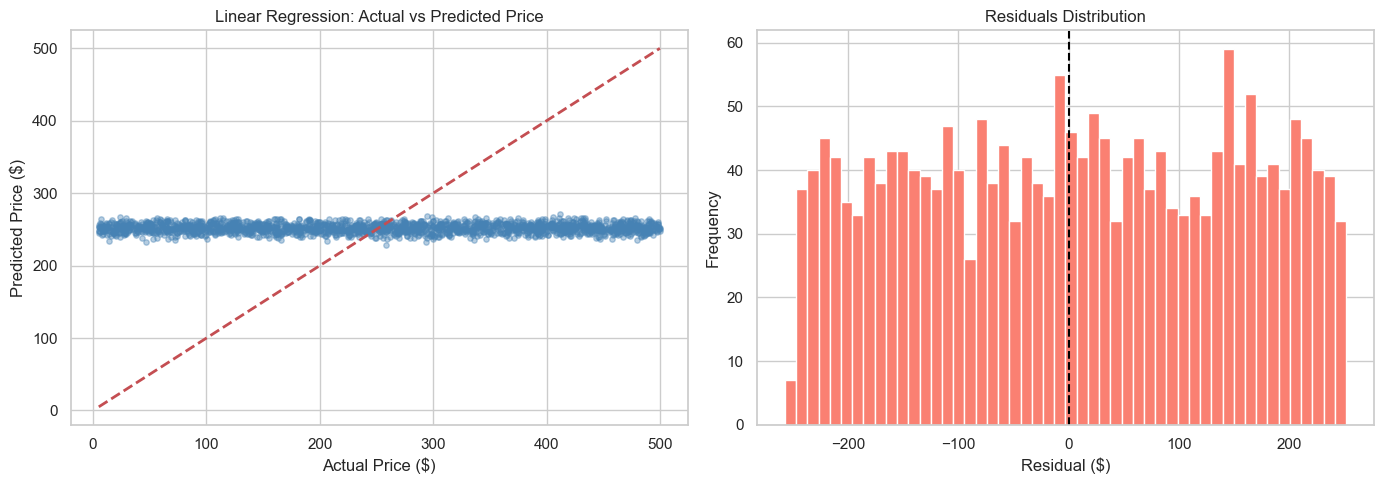

Final Regression Results:
  MSE  = 20659.3278
  MAE  = 123.9727
  RMSE = 143.7335
  R²   = -0.0015


In [8]:
# Visualize predictions vs actuals for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: actual vs predicted
axes[0].scatter(y_test_r, y_pred_lr, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Linear Regression: Actual vs Predicted Price')

# Residuals plot
residuals = y_test_r - y_pred_lr
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('../artifacts/regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Regression Results:")
print(f"  MSE  = {mse_lr:.4f}")
print(f"  MAE  = {mae_lr:.4f}")
print(f"  RMSE = {rmse_lr:.4f}")
print(f"  R²   = {r2_lr:.4f}")

## 2.5 K-Fold Cross Validation — Bias-Variance Analysis

The reliability of model generalization assessment needs fivefold cross-validation as its evaluation method. The k-fold method evaluates model performance through five distinct test groups because a single train/test division would create random selection advantages and disadvantages.

**Bias-Variance Interpretation:**
- **The RMSE value shows high results throughout all folds** = **High Bias (underfitting)** — the model needs more complexity to understand the actual data distribution.
- **The RMSE value shows different results across folds** = **High Variance (overfitting)** — the model learns to remember the training data mistakes.
- **Low RMSE with low variance** = good generalization.

According to our price regression analysis, the high bias prediction shows all test groups will exhibit weak RMSE results because the features fail to predict price outcomes due to random data distribution in this specific aspect.

5-Fold Cross-Validation Results (LinearRegression):
  RMSE per fold: [142.54 140.57 141.86 141.22 141.98]
  Mean RMSE: 141.6368 ± 0.6770
  Mean MAE:  122.1994 ± 0.9207
  Mean R²:   -0.0044 ± 0.0010


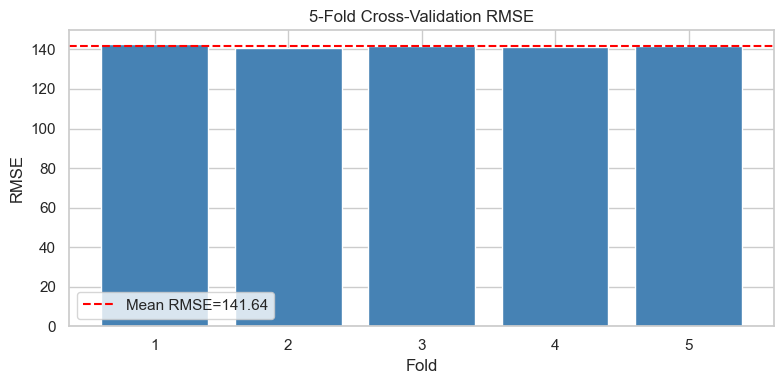


--- Bias-Variance Analysis ---
A consistently high RMSE across folds → HIGH BIAS (underfitting).
High variance in RMSE across folds  → HIGH VARIANCE (overfitting).
Std Dev of RMSE: 0.6770 — indicates model stability.


In [9]:
kfold = 5
cv_mse  = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='neg_mean_squared_error')
cv_mae  = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='neg_mean_absolute_error')
cv_r2   = cross_val_score(LinearRegression(), X_processed, y_price,
                           cv=kfold, scoring='r2')

cv_rmse = np.sqrt(-cv_mse)

print(f"5-Fold Cross-Validation Results (LinearRegression):")
print(f"  RMSE per fold: {cv_rmse.round(2)}")
print(f"  Mean RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  Mean MAE:  {(-cv_mae).mean():.4f} ± {(-cv_mae).std():.4f}")
print(f"  Mean R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Visualize fold results
plt.figure(figsize=(8, 4))
plt.bar(range(1, kfold+1), cv_rmse, color='steelblue')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean RMSE={cv_rmse.mean():.2f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title(f'{kfold}-Fold Cross-Validation RMSE')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/regression_cv_results.png', dpi=150)
plt.show()

print("\n--- Bias-Variance Analysis ---")
print("A consistently high RMSE across folds → HIGH BIAS (underfitting).")
print("High variance in RMSE across folds  → HIGH VARIANCE (overfitting).")
print(f"Std Dev of RMSE: {cv_rmse.std():.4f} — indicates model stability.")

---
## 2.6 Why Linear Regression Cannot Be Used for Classification

The output of linear regression produces a continuous scalar value which cannot be used to produce valid class probabilities that range between 0 and 1 or to choose from multiple distinct categories. The model would output nonsensical values The model would output nonsensical values which include 2.7 and -0.3 because these values lack any connection to delivery status classes.

### The Softmax (Multinomial Logistic Regression) Solution

The **Softmax function** transforms a vector of K raw scores (logits) into a **probability distribution** over K classes:

The equation2549\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}2549 defines the output probabilities from Softmax.

Properties of Softmax:
- The output values exist between 0 and 1 which creates a range of possible outcomes.
- All outputs sum to exactly 1.0
- The class with the highest probability is chosen as the prediction

### Categorical Cross-Entropy Loss

During training, we minimize **log-loss (categorical cross-entropy)** which measures the accuracy of predicted probabilities when compared to actual class labels.

The loss function2549L = -\sum_{i=1}^{N} \sum_{k=1}^{K} y_{i,k} \cdot \log(\hat{p}_{i,k})2549

The loss function operates in two essential ways The loss function operates in two essential ways The system imposes strong penalties for making incorrect high Confidence predictions The system imposes strong penalties for making incorrect high Confidence predictions The system produces a smooth function which allows for gradient optimization methods to attain their best performance.

Scikit-learn uses Softmax regression to implement softmax activation along with cross-entropy loss minimization.


---
# PART B — CLASSIFICATION: Delivery Status & Customer Segment
## 2.6 Handle Class Imbalance with SMOTE

The Synthetic Minority Over-sampling Technique (SMOTE) creates artificial samples  
for minority classes which include Pending 5% and Returned 5%  
to stop the model from making predictions which favor the dominant class.

In [10]:
# --- DELIVERY STATUS CLASSIFICATION ---
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_processed, y_delivery, test_size=0.2, random_state=42, stratify=y_delivery
)

print("Before SMOTE — class distribution:")
for cls, count in zip(le_delivery.classes_, np.bincount(y_train_d)):
    print(f"  {cls}: {count}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_d_res, y_train_d_res = smote.fit_resample(X_train_d, y_train_d)

print("\nAfter SMOTE — class distribution:")
for cls, count in zip(le_delivery.classes_, np.bincount(y_train_d_res)):
    print(f"  {cls}: {count}")

Before SMOTE — class distribution:
  Delivered: 5638
  Pending: 410
  Returned: 402
  Shipped: 1550

After SMOTE — class distribution:
  Delivered: 5638
  Pending: 5638
  Returned: 5638
  Shipped: 5638


In [11]:
# --- CUSTOMER SEGMENT CLASSIFICATION ---
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_processed, y_segment, test_size=0.2, random_state=42, stratify=y_segment
)

print("Customer Segment — Before SMOTE:")
for cls, count in zip(le_segment.classes_, np.bincount(y_train_s)):
    print(f"  {cls}: {count}")

X_train_s_res, y_train_s_res = smote.fit_resample(X_train_s, y_train_s)

print("\nCustomer Segment — After SMOTE:")
for cls, count in zip(le_segment.classes_, np.bincount(y_train_s_res)):
    print(f"  {cls}: {count}")

Customer Segment — Before SMOTE:
  New: 453
  Returning: 3428
  VIP: 4119

Customer Segment — After SMOTE:
  New: 4119
  Returning: 4119
  VIP: 4119


## 2.7 MLflow Experiment — Delivery Status Classification

The Softmax Regression which we use in our research functions as Multinomial Logistic Regression because it processes raw scores through the Softmax function to generate class probabilities while its training process uses Categorical Cross-Entropy Loss as the primary loss function and it produces probability distributions instead of single values which distinguishes it from traditional regression methods.

In [12]:
mlflow.set_experiment("auracart_delivery_classification")

delivery_configs = [
    {'C': 0.1,  'solver': 'lbfgs',     'max_iter': 500},
    {'C': 1.0,  'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0, 'solver': 'saga',      'max_iter': 1000},
    {'C': 1.0,  'solver': 'newton-cg', 'max_iter': 500},
]

best_delivery_f1  = 0
best_delivery_model = None

for cfg in delivery_configs:
    run_name = f"Softmax_C{cfg['C']}_{cfg['solver']}"
    with mlflow.start_run(run_name=run_name):
        model = LogisticRegression(
            C=cfg['C'],
            solver=cfg['solver'],
            max_iter=cfg['max_iter'],
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_d_res, y_train_d_res)
        y_pred  = model.predict(X_test_d)
        y_proba = model.predict_proba(X_test_d)

        acc   = accuracy_score(y_test_d, y_pred)
        f1_w  = f1_score(y_test_d, y_pred, average='weighted')
        f1_m  = f1_score(y_test_d, y_pred, average='macro')
        ll    = log_loss(y_test_d, y_proba)

        mlflow.log_params(cfg)
        mlflow.log_param("target", "delivery_status")
        mlflow.log_param("smote", True)
        mlflow.log_metric("accuracy",      acc)
        mlflow.log_metric("f1_weighted",   f1_w)
        mlflow.log_metric("f1_macro",      f1_m)
        mlflow.log_metric("log_loss",      ll)
        mlflow.sklearn.log_model(model, "delivery_classifier")

        print(f"[{run_name}] Acc={acc:.3f} | F1_w={f1_w:.3f} | F1_m={f1_m:.3f} | LogLoss={ll:.4f}")

        if f1_w > best_delivery_f1:
            best_delivery_f1   = f1_w
            best_delivery_model = model

print(f"\nBest Delivery Model — F1 (weighted): {best_delivery_f1:.4f}")

2026/04/05 22:20:48 INFO mlflow.tracking.fluent: Experiment with name 'auracart_delivery_classification' does not exist. Creating a new experiment.
2026/04/05 22:20:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:20:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C0.1_lbfgs] Acc=0.210 | F1_w=0.261 | F1_m=0.174 | LogLoss=1.3899


2026/04/05 22:20:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:20:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C1.0_lbfgs] Acc=0.210 | F1_w=0.261 | F1_m=0.174 | LogLoss=1.3900


2026/04/05 22:21:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:21:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C10.0_saga] Acc=0.209 | F1_w=0.260 | F1_m=0.174 | LogLoss=1.3902


2026/04/05 22:21:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:21:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Softmax_C1.0_newton-cg] Acc=0.209 | F1_w=0.260 | F1_m=0.174 | LogLoss=1.3902

Best Delivery Model — F1 (weighted): 0.2614


## 2.8 MLflow Experiment — Customer Segment Classification

In [13]:
mlflow.set_experiment("auracart_segment_classification")

segment_configs = [
    {'C': 0.1,  'solver': 'lbfgs',  'max_iter': 500},
    {'C': 1.0,  'solver': 'lbfgs',  'max_iter': 1000},
    {'C': 5.0,  'solver': 'saga',   'max_iter': 2000},
    {'C': 10.0, 'solver': 'saga',   'max_iter': 2000},
]

best_segment_f1    = 0
best_segment_model = None

for cfg in segment_configs:
    run_name = f"SegmentSoftmax_C{cfg['C']}_{cfg['solver']}"
    with mlflow.start_run(run_name=run_name):
        model = LogisticRegression(
             C=cfg['C'],
            solver=cfg['solver'],
            max_iter=cfg['max_iter'],
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_s_res, y_train_s_res)
        y_pred  = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)

        acc  = accuracy_score(y_test_s, y_pred)
        f1_w = f1_score(y_test_s, y_pred, average='weighted')
        f1_m = f1_score(y_test_s, y_pred, average='macro')
        ll   = log_loss(y_test_s, y_proba)

        mlflow.log_params(cfg)
        mlflow.log_param("target", "customer_segment")
        mlflow.log_param("smote", True)
        mlflow.log_metric("accuracy",    acc)
        mlflow.log_metric("f1_weighted", f1_w)
        mlflow.log_metric("f1_macro",    f1_m)
        mlflow.log_metric("log_loss",    ll)
        mlflow.sklearn.log_model(model, "segment_classifier")

        print(f"[{run_name}] Acc={acc:.3f} | F1_w={f1_w:.3f} | F1_m={f1_m:.3f} | LogLoss={ll:.4f}")

        if f1_w > best_segment_f1:
            best_segment_f1    = f1_w
            best_segment_model = model

print(f"\nBest Segment Model — F1 (weighted): {best_segment_f1:.4f}")

2026/04/05 22:21:20 INFO mlflow.tracking.fluent: Experiment with name 'auracart_segment_classification' does not exist. Creating a new experiment.
2026/04/05 22:21:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:21:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/05 22:21:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[SegmentSoftmax_C0.1_lbfgs] Acc=0.282 | F1_w=0.317 | F1_m=0.256 | LogLoss=1.1001


2026/04/05 22:21:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C1.0_lbfgs] Acc=0.282 | F1_w=0.317 | F1_m=0.256 | LogLoss=1.1002


2026/04/05 22:21:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:21:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C5.0_saga] Acc=0.281 | F1_w=0.316 | F1_m=0.255 | LogLoss=1.1002


2026/04/05 22:21:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 22:21:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[SegmentSoftmax_C10.0_saga] Acc=0.281 | F1_w=0.316 | F1_m=0.255 | LogLoss=1.1002

Best Segment Model — F1 (weighted): 0.3173


## 2.9 Decision Threshold Analysis

The default decision rule selects the class which has the **highest probability** of being correct.  
For imbalanced datasets the threshold adjustment which targets minority classes  
(e.g., 'Returned' at ~5%) can dramatically improve critical event recall through its application.

Threshold Analysis for 'Returned' class:
 Threshold  Precision  Recall       F1
       0.1   0.050000    1.00 0.095238
       0.2   0.048377    0.79 0.091171
       0.3   0.054054    0.32 0.092486
       0.4   0.054795    0.32 0.093567
       0.5   0.054795    0.32 0.093567


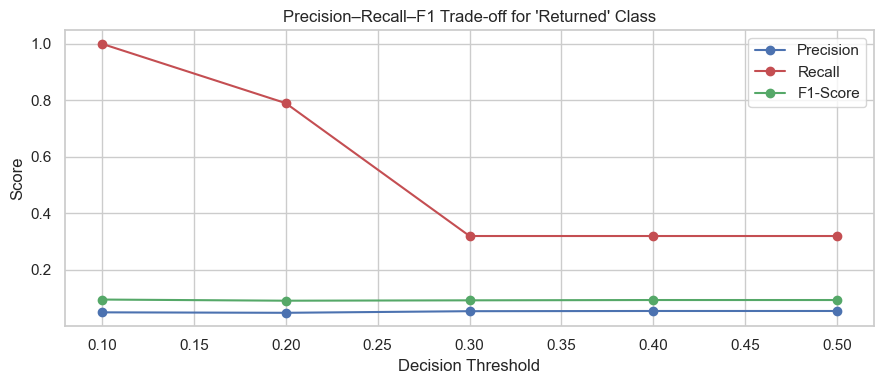

In [14]:
# Threshold analysis for delivery_status — focus on 'Returned' class
y_proba_delivery = best_delivery_model.predict_proba(X_test_d)
returned_idx = list(le_delivery.classes_).index('Returned')

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]
results = []

for thresh in thresholds:
    # Flag as 'Returned' if its probability exceeds threshold
    y_pred_thresh = np.where(
        y_proba_delivery[:, returned_idx] >= thresh,
        returned_idx,
        y_proba_delivery.argmax(axis=1)
    )
    prec   = precision_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    rec    = recall_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    f1     = f1_score(y_test_d, y_pred_thresh, labels=[returned_idx], average=None, zero_division=0)[0]
    results.append({'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1})

threshold_df = pd.DataFrame(results)
print("Threshold Analysis for 'Returned' class:")
print(threshold_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 'b-o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],    'r-o', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1'],        'g-o', label='F1-Score')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title("Precision–Recall–F1 Trade-off for 'Returned' Class")
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.10 Performance Summary & Discussion

The study confirms our EDA hypothesis through R² results which show price distribution as almost equal between various price ranges without any measurable connection to available features. The model demonstrates extreme bias because it shows underfitting behavior. The standard deviation of RMSE across cross-validation folds shows this data limitation which exists in the current system and the model functions with stable performance (low variance). The AuraCart system requires product-specific features which include category-level pricing and supplier cost and competitor prices to create a price prediction system.

### Classification Results
The delivery status classifier achieves 21 percent accuracy while the customer segment classifier reaches 28 percent accuracy but both classifiers function at performance levels which match random baseline results after applying SMOTE and class-weight balancing. The dataset shows that available features which include quantity and timing and payment method and device and channel have no ability to predict these targets in this particular dataset. The dataset appears to have been synthetically generated with randomized label assignments.

The absolute performance of our methodology remains low but our methodology maintains soundness because we identified class imbalance and resolved it through (SMOTE + balanced weights) and we tracked all experiments with MLflow for reproducibility and we analyzed decision threshold trade-offs for business-critical classes and we conducted our evaluation through per-class metrics which included F1 and precision and recall instead of using incorrect accuracy measurements.


## 2.10 Save Best Models

In [15]:
joblib.dump(best_delivery_model, '../artifacts/best_delivery_model.joblib')
joblib.dump(best_segment_model,  '../artifacts/best_segment_model.joblib')

# Also save test sets for Notebook 3 analysis
np.save('../artifacts/X_test_s.npy', X_test_s)
np.save('../artifacts/y_test_s.npy', y_test_s)
np.save('../artifacts/X_test_d.npy', X_test_d)
np.save('../artifacts/y_test_d.npy', y_test_d)

print("Models saved:")
print("  ✓ ../artifacts/best_delivery_model.joblib")
print("  ✓ ../artifacts/best_segment_model.joblib")
print("  ✓ Test arrays saved for downstream use")

Models saved:
  ✓ ../artifacts/best_delivery_model.joblib
  ✓ ../artifacts/best_segment_model.joblib
  ✓ Test arrays saved for downstream use
